In [118]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

In [62]:
file_path = 'C:\\Users\\49176\\Task3\\Day-ahead Prices_202401010000-202501010000.csv'
file_path2 ='C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202401010000-202501010000.csv'
day_ahead_prices= read_csv(file_path, low_memory=False)
generation_data_columns=read_csv(file_path2, low_memory=False)

In [107]:
# Show columns
print(day_ahead_prices.columns)
print(generation_data.columns)

Index(['MTU (CET/CEST)', 'Day-ahead Price [EUR/MWh]', 'Currency', 'BZN|DE-LU',
       'timestamp'],
      dtype='object')
Index(['Area', 'MTU', 'Biomass - Actual Aggregated [MW]',
       'Energy storage - Actual Aggregated [MW]',
       'Fossil Brown coal/Lignite - Actual Aggregated [MW]',
       'Fossil Coal-derived gas - Actual Aggregated [MW]',
       'Fossil Gas - Actual Aggregated [MW]',
       'Fossil Hard coal - Actual Aggregated [MW]',
       'Fossil Oil - Actual Aggregated [MW]',
       'Fossil Oil shale - Actual Aggregated [MW]',
       'Fossil Peat - Actual Aggregated [MW]',
       'Geothermal - Actual Aggregated [MW]',
       'Hydro Pumped Storage - Actual Aggregated [MW]',
       'Hydro Pumped Storage - Actual Consumption [MW]',
       'Hydro Run-of-river and poundage - Actual Aggregated [MW]',
       'Hydro Water Reservoir - Actual Aggregated [MW]',
       'Marine - Actual Aggregated [MW]', 'Nuclear - Actual Aggregated [MW]',
       'Other - Actual Aggregated [MW]',
     

In [65]:
# convert
day_ahead_prices['timestamp'] = pd.to_datetime(
    day_ahead_prices['MTU (CET/CEST)'].str.split(' - ').str[0], 
    dayfirst=True
)

generation_data['timestamp'] = pd.to_datetime(
    generation_data['MTU'].str.split(' - ').str[0], 
    dayfirst=True
)


In [66]:
# check if type is correct
print("Zeitstempel aus Day-ahead Prices:")
print(day_ahead_prices['timestamp'].head())

print("\nZeitstempel aus Actual Generation:")
print(generation_data['timestamp'].head())


Zeitstempel aus Day-ahead Prices:
0   2024-01-01 00:00:00
1   2024-01-01 00:15:00
2   2024-01-01 00:30:00
3   2024-01-01 00:45:00
4   2024-01-01 01:00:00
Name: timestamp, dtype: datetime64[ns]

Zeitstempel aus Actual Generation:
0   2024-01-01 00:00:00
1   2024-01-01 00:15:00
2   2024-01-01 00:30:00
3   2024-01-01 00:45:00
4   2024-01-01 01:00:00
Name: timestamp, dtype: datetime64[ns]


In [69]:
# merge the datasets
merged_data = pd.merge(day_ahead_prices, generation_data, on='timestamp', how='inner')

# check if the merge was succesfully
print("Zusammengeführte Daten:")
print(merged_data.head())


Zusammengeführte Daten:
                        MTU (CET/CEST) Day-ahead Price [EUR/MWh] Currency  \
0  01.01.2024 00:00 - 01.01.2024 00:15                     39.91      EUR   
1  01.01.2024 00:15 - 01.01.2024 00:30                     -0.04      EUR   
2  01.01.2024 00:30 - 01.01.2024 00:45                     -9.01      EUR   
3  01.01.2024 00:45 - 01.01.2024 01:00                    -29.91      EUR   
4  01.01.2024 01:00 - 01.01.2024 01:15                     25.28      EUR   

   BZN|DE-LU           timestamp    Area  \
0        NaN 2024-01-01 00:00:00  BZN|ES   
1        NaN 2024-01-01 00:15:00  BZN|ES   
2        NaN 2024-01-01 00:30:00  BZN|ES   
3        NaN 2024-01-01 00:45:00  BZN|ES   
4        NaN 2024-01-01 01:00:00  BZN|ES   

                                              MTU  \
0  01.01.2024 00:00 - 01.01.2024 00:15 (CET/CEST)   
1  01.01.2024 00:15 - 01.01.2024 00:30 (CET/CEST)   
2  01.01.2024 00:30 - 01.01.2024 00:45 (CET/CEST)   
3  01.01.2024 00:45 - 01.01.2024 01:

In [71]:
#delete not important clumns
merged_data.drop(columns=['MTU (CET/CEST)', 'Currency', 'BZN|DE-LU', 'Area', 'MTU'], inplace=True)

# NAN values in 0
merged_data.fillna(value=0, inplace=True)

# Delete NaN Values in columns
merged_data = merged_data[merged_data['Day-ahead Price [EUR/MWh]'].notna()]

# Check if the convertion happened
print("Anzahl NaN-Werte pro Spalte nach der Bereinigung:")
print(merged_data.isna().sum())


Anzahl NaN-Werte pro Spalte nach der Bereinigung:
Day-ahead Price [EUR/MWh]                                   0
timestamp                                                   0
Biomass - Actual Aggregated [MW]                            0
Energy storage - Actual Aggregated [MW]                     0
Fossil Brown coal/Lignite - Actual Aggregated [MW]          0
Fossil Coal-derived gas - Actual Aggregated [MW]            0
Fossil Gas - Actual Aggregated [MW]                         0
Fossil Hard coal - Actual Aggregated [MW]                   0
Fossil Oil - Actual Aggregated [MW]                         0
Fossil Oil shale - Actual Aggregated [MW]                   0
Fossil Peat - Actual Aggregated [MW]                        0
Geothermal - Actual Aggregated [MW]                         0
Hydro Pumped Storage - Actual Aggregated [MW]               0
Hydro Pumped Storage - Actual Consumption [MW]              0
Hydro Run-of-river and poundage - Actual Aggregated [MW]    0
Hydro Water Reservoi

In [73]:
# check if timestamp is in datetime
merged_data['timestamp'] = pd.to_datetime(merged_data['timestamp'], errors='coerce')

print(merged_data['timestamp'].head())


0   2024-01-01 00:00:00
1   2024-01-01 00:15:00
2   2024-01-01 00:30:00
3   2024-01-01 00:45:00
4   2024-01-01 01:00:00
Name: timestamp, dtype: datetime64[ns]


In [74]:
# extraxt weekday and hour
merged_data['hour'] = merged_data['timestamp'].dt.hour
merged_data['weekday'] = merged_data['timestamp'].dt.weekday

# check hour and weekday
print(merged_data[['hour', 'weekday']].head())


   hour  weekday
0     0        0
1     0        0
2     0        0
3     0        0
4     1        0


In [80]:

# Aimvariable (Day-ahead-Price)
y = merged_data['Day-ahead Price [EUR/MWh]']

# Pradicator (Features)
X = merged_data[['renewable_share', 'total_generation', 'hour', 'weekday']]

# Split data into test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check if successfully
print("Form von X_train:", X_train.shape)
print("Form von X_test:", X_test.shape)
print("Form von y_train:", y_train.shape)
print("Form von y_test:", y_test.shape)

X_train['renewable_share'] = X_train['renewable_share'].fillna(0)
X_test['renewable_share'] = X_test['renewable_share'].fillna(0)


Form von X_train: (28118, 4)
Form von X_test: (7030, 4)
Form von y_train: (28118,)
Form von y_test: (7030,)


In [119]:
# Check if there are no NaN-Values
print("NaN-Values in X_train:")
print(X_train.isna().sum())

print("\nNaN-Values in X_test:")
print(X_test.isna().sum())


NaN-Values in X_train:
renewable_share     0
total_generation    0
hour                0
weekday             0
dtype: int64

NaN-Values in X_test:
renewable_share     0
total_generation    0
hour                0
weekday             0
dtype: int64


In [82]:
# linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# prediction
y_pred_lr = lr.predict(X_test)

# evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression - R²-Score: {r2_lr:.2f}")


Linear Regression - Mean Squared Error (MSE): 2310.43
Linear Regression - R²-Score: 0.05


C:\Users\49176\AppData\Local\Temp\ipykernel_12736\639342881.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2)


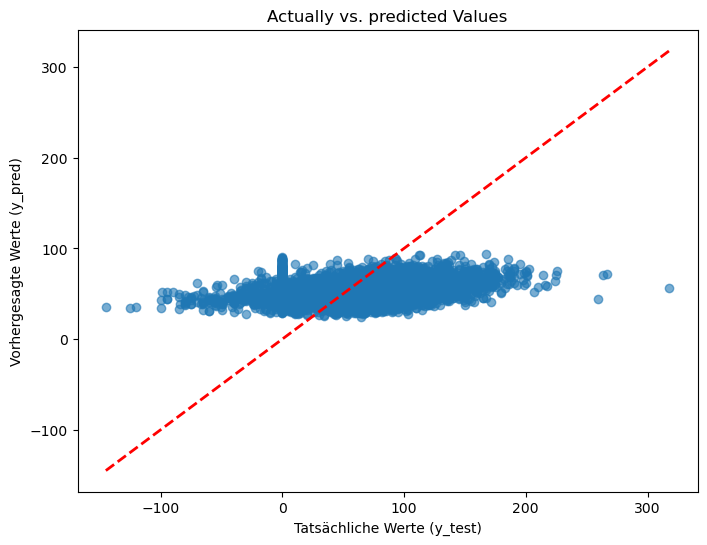

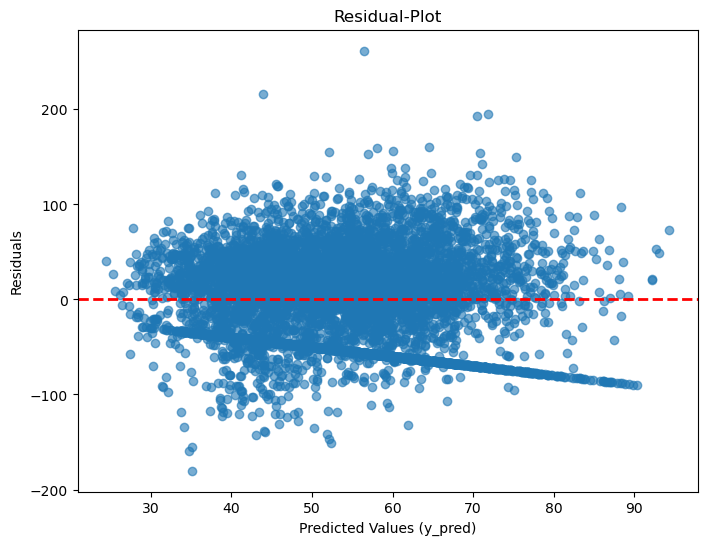

In [120]:

# Comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2)
plt.xlabel('Tatsächliche Werte (y_test)')
plt.ylabel('Vorhergesagte Werte (y_pred)')
plt.title('Actually vs. predicted Values')
plt.show()

# Residual-Plot
residuals = y_test - y_pred_lr
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals')
plt.title('Residual-Plot')
plt.show()


In [86]:


# Random Forest Regressor initilize
rf = RandomForestRegressor(random_state=42, n_estimators=100)

# Training 
rf.fit(X_train, y_train)

#Prediction
y_pred_rf = rf.predict(X_test)

# evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - R²-Score: {r2_rf:.2f}")


Random Forest - Mean Squared Error (MSE): 1433.78
Random Forest - R²-Score: 0.41


C:\Users\49176\AppData\Local\Temp\ipykernel_12736\3491003500.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")


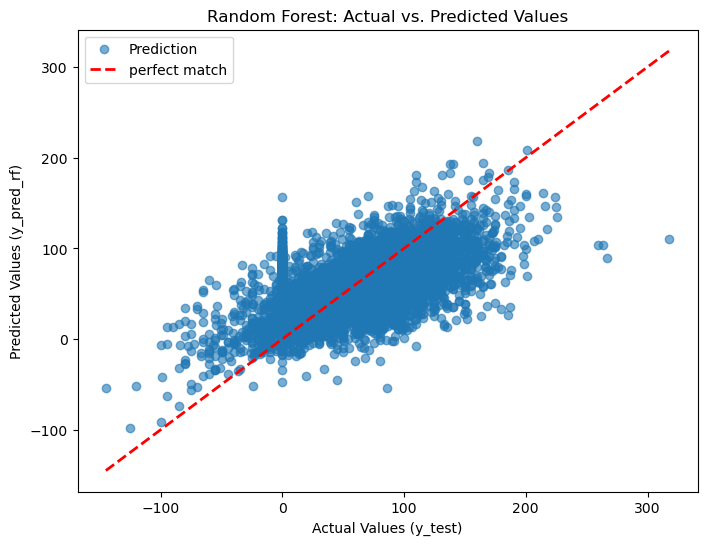

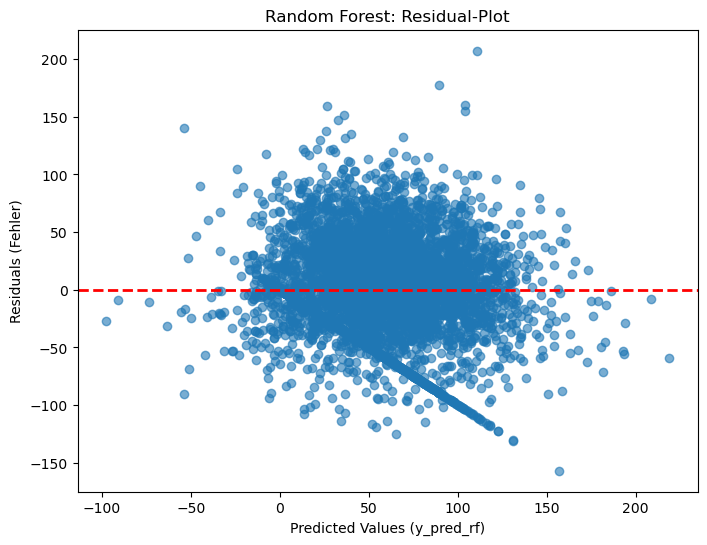

In [122]:


#Comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred_rf)')
plt.title('Random Forest: Actual vs. Predicted Values')
plt.legend()
plt.show()

# Residual-Plot
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values (y_pred_rf)')
plt.ylabel('Residuals (Fehler)')
plt.title('Random Forest: Residual-Plot')
plt.show()


In [88]:


# Gradient Boosting Regressor initilize
gbr = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)

# Training model
gbr.fit(X_train, y_train)

# Prediction
y_pred_gbr = gbr.predict(X_test)

# evaluation
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting - R²-Score: {r2_gbr:.2f}")


Gradient Boosting - Mean Squared Error (MSE): 1783.50
Gradient Boosting - R²-Score: 0.27


C:\Users\49176\AppData\Local\Temp\ipykernel_12736\3271739086.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")


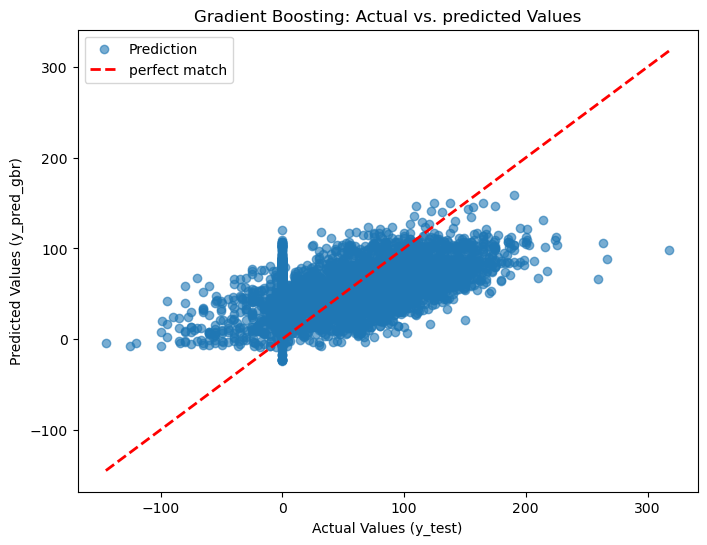

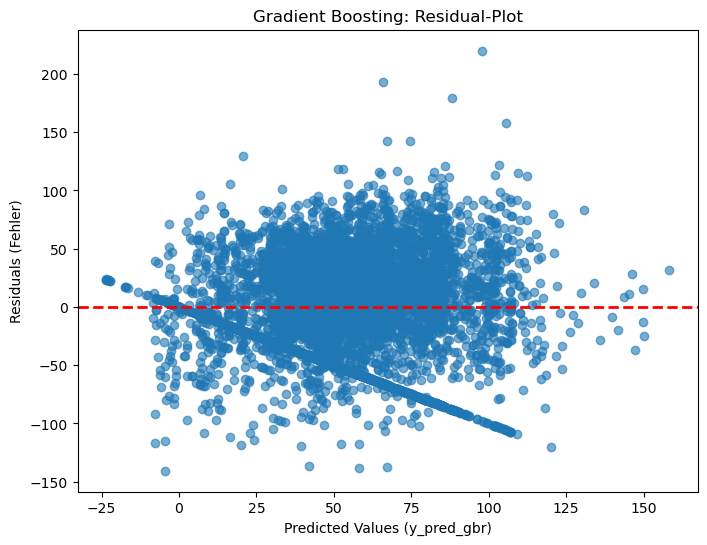

In [123]:


# comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gbr, alpha=0.6, label="Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred_gbr)')
plt.title('Gradient Boosting: Actual vs. predicted Values')
plt.legend()
plt.show()

# Residual-Plot
residuals_gbr = y_test - y_pred_gbr
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_gbr, residuals_gbr, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values (y_pred_gbr)')
plt.ylabel('Residuals (Fehler)')
plt.title('Gradient Boosting: Residual-Plot')
plt.show()


In [90]:


# SVR initilize
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Training model
svr.fit(X_train, y_train)

# Prediction of testdata
y_pred_svr = svr.predict(X_test)

# evaluation
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Support Vector Regression - Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Support Vector Regression - R²-Score: {r2_svr:.2f}")


Support Vector Regression - Mean Squared Error (MSE): 2425.14
Support Vector Regression - R²-Score: 0.00


In [94]:


# XGBoost Regressor initilize
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Training model
xgb.fit(X_train, y_train)

# prediction testdata
y_pred_xgb = xgb.predict(X_test)

# Evaluation 
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regression - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regression - R²-Score: {r2_xgb:.2f}")


XGBoost Regression - Mean Squared Error (MSE): 1791.17
XGBoost Regression - R²-Score: 0.26


C:\Users\49176\AppData\Local\Temp\ipykernel_12736\644925257.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")


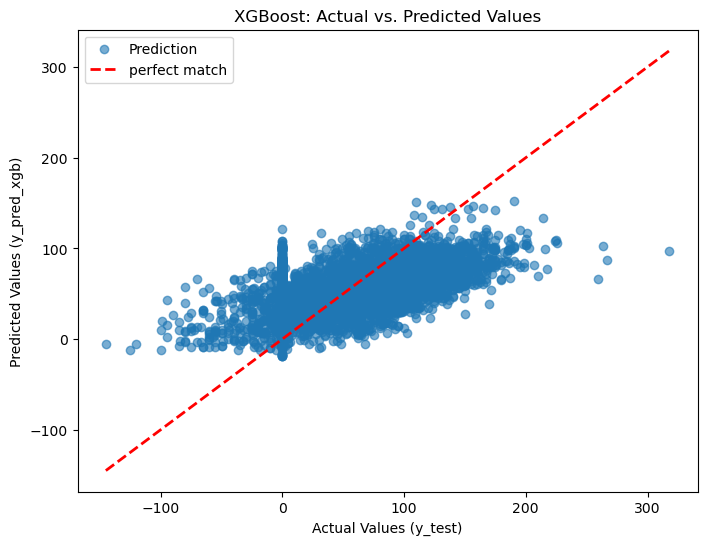

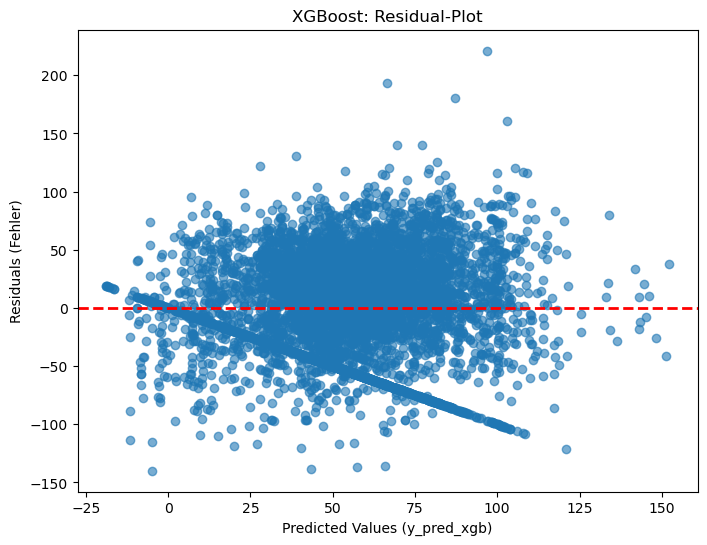

In [124]:

#Comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, label="Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred_xgb)')
plt.title('XGBoost: Actual vs. Predicted Values')
plt.legend()
plt.show()

# Residual-Plot
residuals_xgb = y_test - y_pred_xgb
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values (y_pred_xgb)')
plt.ylabel('Residuals (Fehler)')
plt.title('XGBoost: Residual-Plot')
plt.show()


In [98]:
# LightGBM Regressor initilize
lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Training  Model
lgbm.fit(X_train, y_train)

# prediction for testdata
y_pred_lgbm = lgbm.predict(X_test)

# evaluation
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"LightGBM Regression - Mean Squared Error (MSE): {mse_lgbm:.2f}")
print(f"LightGBM Regression - R²-Score: {r2_lgbm:.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 541
[LightGBM] [Info] Number of data points in the train set: 28118, number of used features: 4
[LightGBM] [Info] Start training from score 53.312153
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

C:\Users\49176\AppData\Local\Temp\ipykernel_12736\3856854153.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")


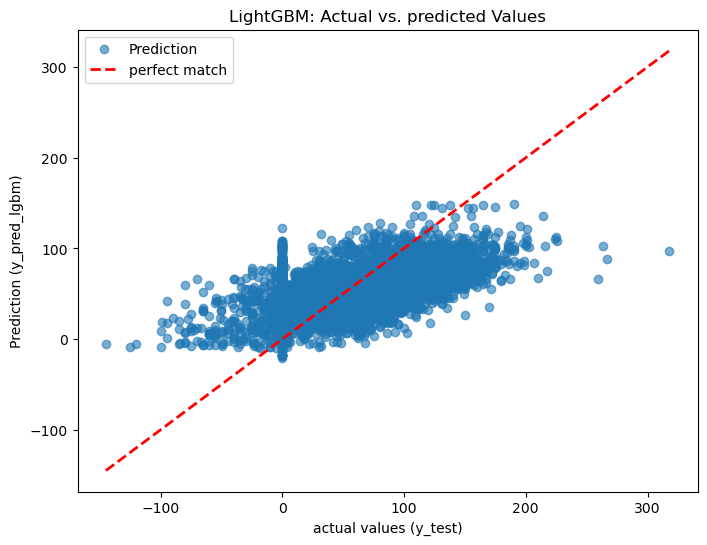

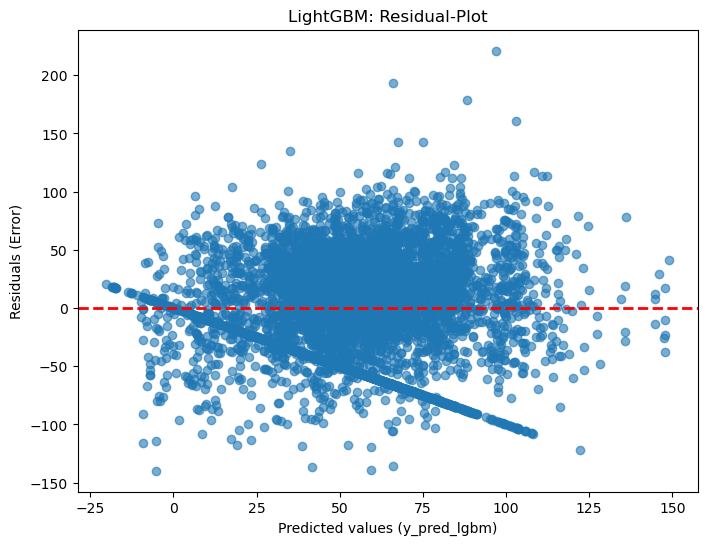

In [125]:


# Comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.6, label="Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label="perfect match")
plt.xlabel('actual values (y_test)')
plt.ylabel('Prediction (y_pred_lgbm)')
plt.title('LightGBM: Actual vs. predicted Values')
plt.legend()
plt.show()

# Residual-Plot
residuals_lgbm = y_test - y_pred_lgbm
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lgbm, residuals_lgbm, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted values (y_pred_lgbm)')
plt.ylabel('Residuals (Error)')
plt.title('LightGBM: Residual-Plot')
plt.show()


In [100]:

# New Random Forest Modell initilize
rf_new = RandomForestRegressor(random_state=42)

# Parameter for optimizing
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # maximum of depth
    'min_samples_split': [2, 5, 10],  # minimum number of samples
    'min_samples_leaf': [1, 2, 4]  # minimum of samples in one leaf
}

# setup gridsearch
grid_search = GridSearchCV(estimator=rf_new, param_grid=param_grid, cv=3, scoring='r2', verbose=2, n_jobs=-1)

# optimize
grid_search.fit(X_train, y_train)

# best parameter
print(f"Beste Parameter: {grid_search.best_params_}")

# best parameter for results
rf_optimized = grid_search.best_estimator_
y_pred_rf_optimized = rf_optimized.predict(X_test)

# results of optimized model
mse_rf_optimized = mean_squared_error(y_test, y_pred_rf_optimized)
r2_rf_optimized = r2_score(y_test, y_pred_rf_optimized)

print(f"Optimized Random Forest - Mean Squared Error (MSE): {mse_rf_optimized:.2f}")
print(f"Optimized Random Forest - R²-Score: {r2_rf_optimized:.2f}")
#-->R^2 no increase but MSE slightly better

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Beste Parameter: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Optimiertes Random Forest - Mean Squared Error (MSE): 1428.71
Optimiertes Random Forest - R²-Score: 0.41


In [101]:

# New random forest model
rf_random = RandomForestRegressor(random_state=42)

# Parameter for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    cv=3,       # cross validation
    scoring='r2',  # Resultmetric
    n_jobs=-1,  # cpus
    verbose=2,
    random_state=42 #seed
)

# Training with RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best parameter
print("Beste Parameter:", random_search.best_params_)

# Prediction of test data
best_rf = random_search.best_estimator_
y_pred_random = best_rf.predict(X_test)

# Result
mse_random = mean_squared_error(y_test, y_pred_random)
r2_random = r2_score(y_test, y_pred_random)

print(f"Optimized Random Forest (RandomizedSearchCV) - Mean Squared Error (MSE): {mse_random:.2f}")
print(f"Optimized Random Forest (RandomizedSearchCV) - R²-Score: {r2_random:.2f}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Beste Parameter: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25}
Optimiertes Random Forest (RandomizedSearchCV) - Mean Squared Error (MSE): 1380.14
Optimiertes Random Forest (RandomizedSearchCV) - R²-Score: 0.43


In [102]:
# Feature Importance berechnen
importances = best_rf.feature_importances_

# Features und ihre Importanz in ein DataFrame packen
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# DataFrame nach der Wichtigkeit sortieren
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#Print importance
print(feature_importance_df)


            Feature  Importance
0   renewable_share    0.353530
1  total_generation    0.343433
2              hour    0.191762
3           weekday    0.111275


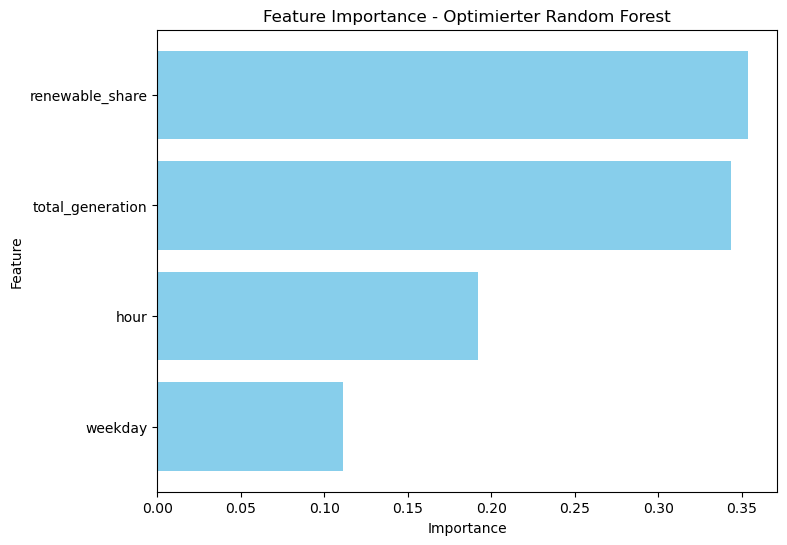

In [127]:
# Barplot for importance
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Optimierter Random Forest')
plt.gca().invert_yaxis()  # 
plt.show()
